In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df = pd.read_csv('/content/drive/MyDrive/Loan_default.csv')

In [7]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [9]:
df.isnull().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop(columns= 'LoanID' , inplace= True)

In [12]:
num_cols = df.select_dtypes('number').drop(columns= 'Default').columns
num_cols

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio'],
      dtype='object')

In [13]:
df['NumCreditLines'].value_counts()

,count
NumCreditLines,
2,64130
3,63834
4,63829
1,63554


In [14]:
def plots(var,num):
    plt.subplot(4,3,num)
    sns.histplot( x = var , kde = True)

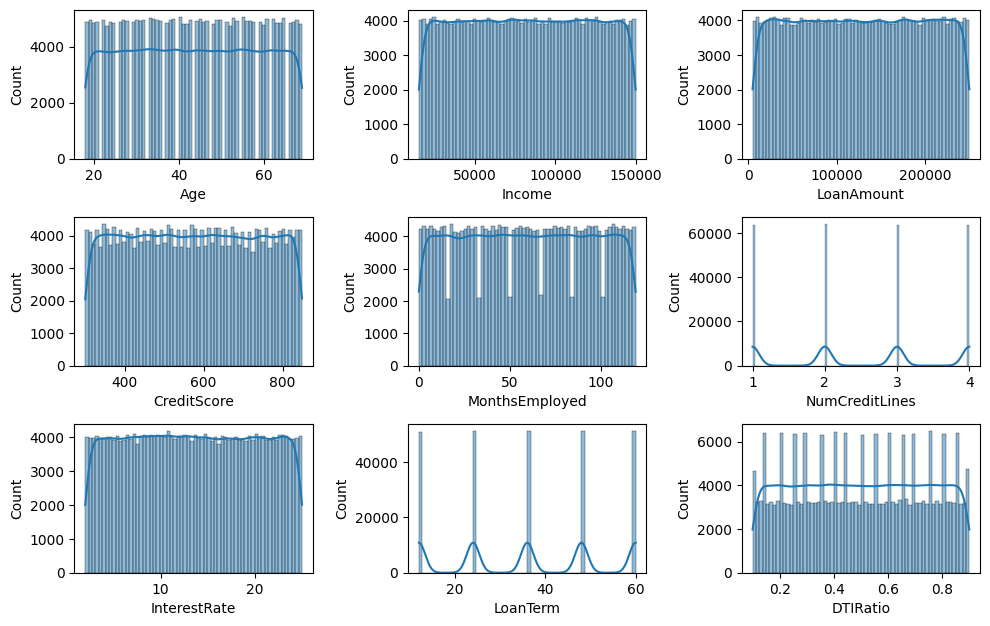

In [15]:
plt.figure(figsize=(10,8))

for i , col in enumerate(num_cols ,1 ):
    plots(df[col] ,i )
    
plt.tight_layout()
plt.show()

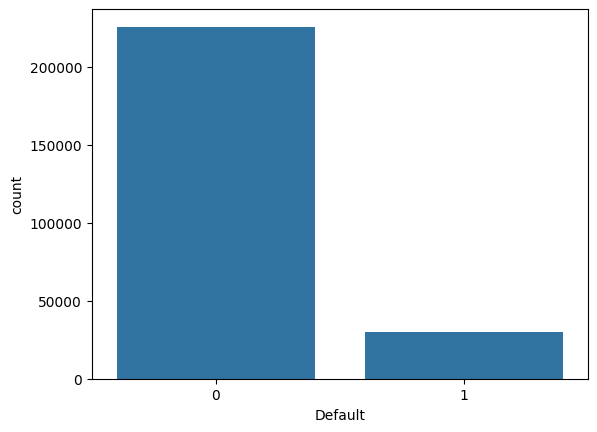

In [16]:
sns.countplot(data= df , x = 'Default' )
plt.show()

In [17]:
cat_cols =df.select_dtypes('object').columns
cat_cols

Index(['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
       'HasDependents', 'LoanPurpose', 'HasCoSigner'],
      dtype='object')

In [18]:
final_cat = list(cat_cols) + ['LoanTerm', 'NumCreditLines']


In [19]:
final_cat

['Education',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage',
 'HasDependents',
 'LoanPurpose',
 'HasCoSigner',
 'LoanTerm',
 'NumCreditLines']

In [20]:
def cat_plots(var, num):
    plt.subplot(3,3,num)
    sns.countplot(data = df , x = var)

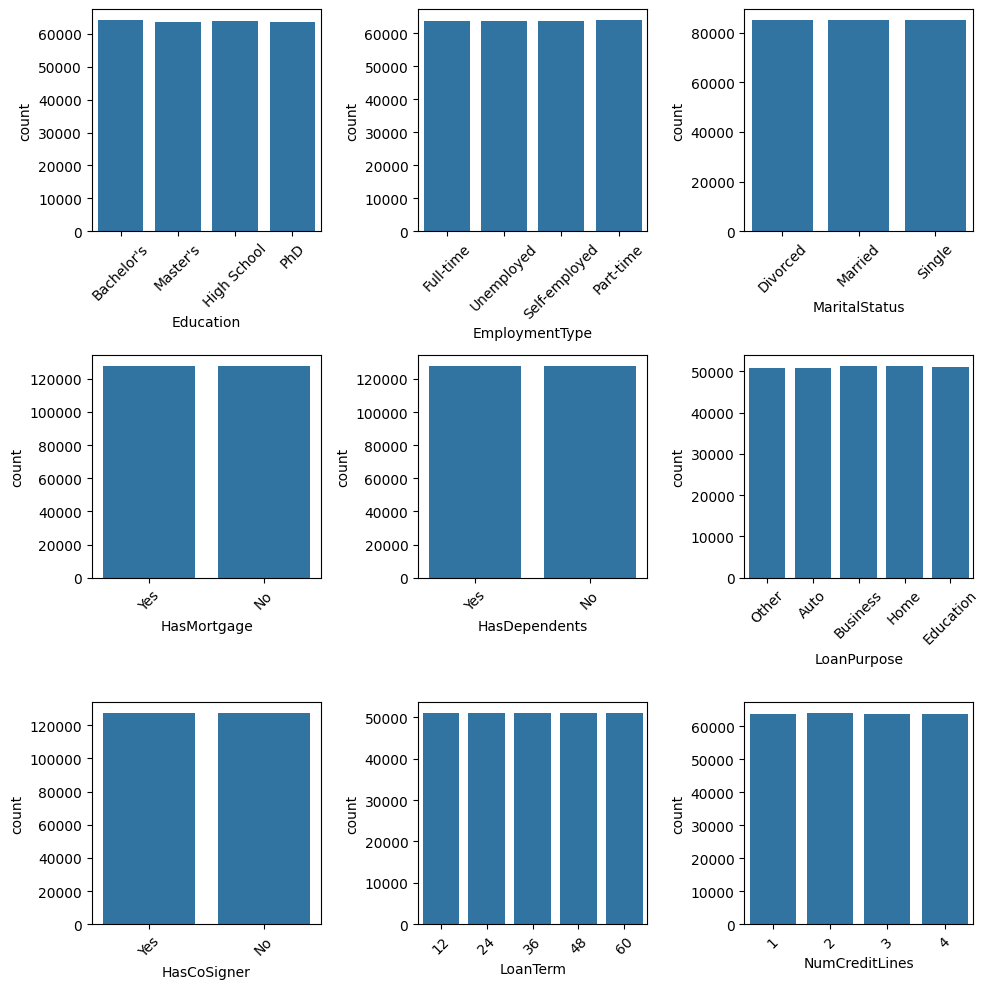

In [21]:
plt.figure(figsize=(10,10))

for i , col in enumerate(final_cat ,1 ):
    cat_plots(df[col],i)
    plt.xticks(rotation = 45)
    
plt.tight_layout()
plt.xticks(rotation = 45)
plt.show()

In [22]:
binary_map = {
    'No': 0 ,
    'Yes': 1 
}

In [23]:
binary_cols = ['HasMortgage', 'HasDependents' , "HasCoSigner"]

In [24]:
for col in binary_cols :
    df[col] = df[col].map(binary_map)

In [25]:
ohe_cols = df.select_dtypes('object').columns
ohe_cols

Index(['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose'], dtype='object')

In [26]:
df= pd.get_dummies(df , columns= ohe_cols , drop_first=False , dtype = int )

In [27]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Auto,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,56,85994,50587,520,80,4,15.23,36,0.44,1,...,0,0,1,0,0,0,0,0,0,1
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,0,0,0,1,0,0,0,0,0,1
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,0,1,1,0,0,1,0,0,0,0
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,0,0,0,1,0,0,1,0,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,0,1,1,0,0,1,0,0,0,0


In [28]:
df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'HasMortgage',
       'HasDependents', 'HasCoSigner', 'Default', 'Education_Bachelor's',
       'Education_High School', 'Education_Master's', 'Education_PhD',
       'EmploymentType_Full-time', 'EmploymentType_Part-time',
       'EmploymentType_Self-employed', 'EmploymentType_Unemployed',
       'MaritalStatus_Divorced', 'MaritalStatus_Married',
       'MaritalStatus_Single', 'LoanPurpose_Auto', 'LoanPurpose_Business',
       'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other'],
      dtype='object')

In [29]:
corr_with_target = df.corr()['Default'].sort_values(ascending= False)
corr_with_target

,Default
Default,1.000000
InterestRate,0.131273
LoanAmount,0.086659
EmploymentType_Unemployed,0.034957
NumCreditLines,0.028330
Education_High School,0.022831
MaritalStatus_Divorced,0.020290
DTIRatio,0.019236
LoanPurpose_Business,0.011162
Education_Bachelor's,0.008848


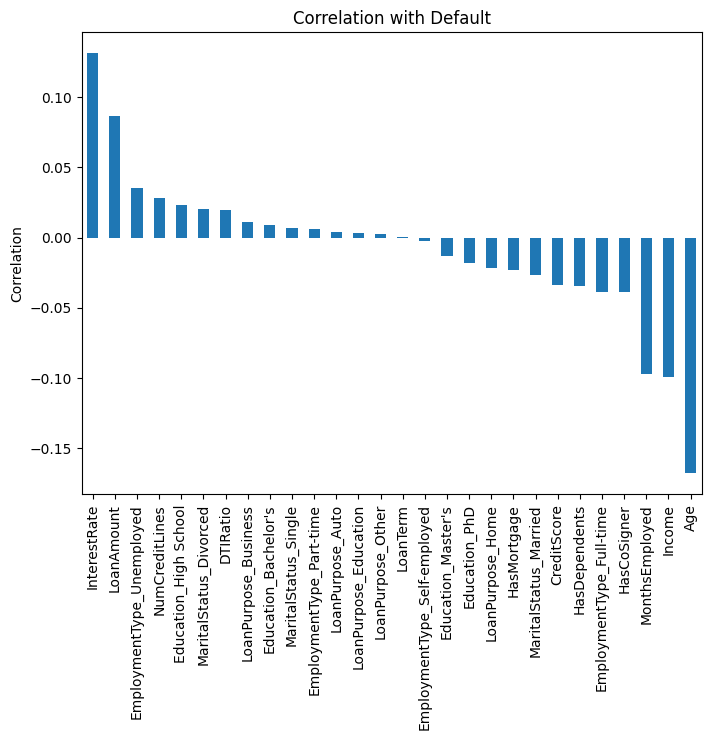

In [30]:
plt.figure(figsize=(8,6))
corr_with_target.drop('Default').plot(kind='bar')
plt.title('Correlation with Default')
plt.ylabel('Correlation')
plt.show()

In [31]:
X = df.drop(columns = 'Default')
y = df['Default']

In [32]:
from sklearn.model_selection import train_test_split


In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 ,stratify= y)

In [34]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_smote, y_train_smote = sm.fit_resample(
    X_train,
    y_train
)

In [35]:
from sklearn.preprocessing import StandardScaler

In [36]:
scaler = StandardScaler()

In [37]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
sm = SMOTE(random_state=42)

X_train_smote_scaled, y_train_smote = sm.fit_resample(
    X_train_scaled,
    y_train
)

# Logistic Regression

In [39]:
from sklearn.linear_model import LogisticRegression

In [40]:
lr= LogisticRegression(random_state= 42, max_iter= 1000)

In [41]:
lr.fit(X_train_smote_scaled , y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

In [42]:
lr_pred = lr.predict(X_test_scaled )

In [43]:
from sklearn.metrics import classification_report , accuracy_score , recall_score , f1_score , roc_auc_score

In [44]:
print(classification_report(y_test , lr_pred))

              precision    recall  f1-score   support

           0       0.94      0.68      0.79     45139
           1       0.22      0.69      0.34      5931

    accuracy                           0.69     51070
   macro avg       0.58      0.69      0.57     51070
weighted avg       0.86      0.69      0.74     51070



In [45]:
print('Accuracy : ' , accuracy_score(y_test , lr_pred))
print('Recall : ' , recall_score(y_test , lr_pred))
print('f1-score : ', f1_score(y_test , lr_pred))
lr_prob = lr.predict_proba(X_test_scaled)[:,1]

print('roc auc: ' , roc_auc_score(y_test, lr_prob))

Accuracy :  0.6853142745251616
Recall :  0.6912830888551678
f1-score :  0.337851757241152
roc auc:  0.7530832476923628


# Random Forest

In [46]:
from sklearn.ensemble import RandomForestClassifier

In [47]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',   
    random_state=42,
    n_jobs=-1
)

In [48]:
rf.fit(X_train , y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [49]:
rf_pred = rf.predict(X_test)

In [50]:
print(classification_report(y_test , rf_pred))

              precision    recall  f1-score   support

           0       0.92      0.89      0.91     45139
           1       0.33      0.39      0.36      5931

    accuracy                           0.83     51070
   macro avg       0.62      0.64      0.63     51070
weighted avg       0.85      0.83      0.84     51070



In [51]:
rf_prob = rf.predict_proba(X_test)[:,1]

print('roc auc: ' , roc_auc_score(y_test, rf_prob))
print('Accuracy : ' , accuracy_score(y_test , rf_pred))
print('Recall : ' , recall_score(y_test , rf_pred))
print('f1-score : ', f1_score(y_test , rf_pred))

roc auc:  0.7535765589561719
Accuracy :  0.8347562169571177
Recall :  0.39403136064744565
f1-score :  0.35644017387325555


# XGBoost

In [52]:
from xgboost import XGBClassifier

In [53]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

In [54]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  
    random_state=42,
    eval_metric='logloss'
)

In [55]:
xgb.fit(X_train , y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [56]:
xgb_pred = xgb.predict(X_test)

In [57]:
print(classification_report(y_test , xgb_pred))

              precision    recall  f1-score   support

           0       0.94      0.71      0.81     45139
           1       0.23      0.67      0.34      5931

    accuracy                           0.70     51070
   macro avg       0.59      0.69      0.58     51070
weighted avg       0.86      0.70      0.75     51070



In [58]:
xgb_prob = xgb.predict_proba(X_test)[:,1]

In [59]:
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1-score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_prob))

Accuracy : 0.7031916976698649
Recall   : 0.6700387792952285
F1-score : 0.34397991863585214
ROC-AUC  : 0.7557996308739796


In [60]:
results = []

In [61]:
results.append({
    'Model':'XGBoost',
    'ROC-AUC': roc_auc_score(y_test, xgb_prob),
    'F1': f1_score(y_test, xgb_pred),
    'Recall': recall_score(y_test, xgb_pred),
    'Accuracy': accuracy_score(y_test, xgb_pred)
})

In [62]:
results.append({
    'Model':'Logistic Regression',
    'ROC-AUC': roc_auc_score(y_test, lr_prob),
    'F1': f1_score(y_test, lr_pred),
    'Recall': recall_score(y_test, lr_pred),
    'Accuracy': accuracy_score(y_test, lr_pred)
})

In [63]:
results.append({
    'Model':'Random Forest',
    'ROC-AUC': roc_auc_score(y_test, rf_prob),
    'F1': f1_score(y_test, rf_pred),
    'Recall': recall_score(y_test, rf_pred),
    'Accuracy': accuracy_score(y_test, rf_pred)
})

In [64]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by='ROC-AUC',
    ascending=False
).reset_index(drop=True)

,Model,ROC-AUC,F1,Recall,Accuracy
0,XGBoost,0.755800,0.343980,0.670039,0.703192
1,Random Forest,0.753577,0.356440,0.394031,0.834756
2,Logistic Regression,0.753083,0.337852,0.691283,0.685314


In [65]:
from sklearn.model_selection import RandomizedSearchCV

In [66]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

In [67]:
xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

In [68]:
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',          # optimize for F1, not accuracy — accuracy is misleading here
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1               # prints progress so you can see it's working
)

In [69]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [4, 6, 8, 10],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='f1', verbose=1)

In [70]:
print("Best params:", random_search.best_params_)
print("Best CV F1:", random_search.best_score_)

Best params: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV F1: 0.3465484387608632


In [71]:
best_xgb = random_search.best_estimator_

xgb_pred_tuned = best_xgb.predict(X_test)
xgb_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_pred_tuned))
print("ROC-AUC :", roc_auc_score(y_test, xgb_prob_tuned))


              precision    recall  f1-score   support

           0       0.94      0.74      0.83     45139
           1       0.24      0.62      0.35      5931

    accuracy                           0.73     51070
   macro avg       0.59      0.68      0.59     51070
weighted avg       0.86      0.73      0.77     51070

ROC-AUC : 0.751648286359395


In [72]:
print("Accuracy :", accuracy_score(y_test, xgb_pred_tuned))
print("Recall   :", recall_score(y_test, xgb_pred_tuned))
print("F1-score :", f1_score(y_test, xgb_pred_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_prob_tuned))

Accuracy : 0.7308791854317603
Recall   : 0.62400944191536
F1-score : 0.3500425612408966
ROC-AUC  : 0.751648286359395


In [73]:
results.append({
    'Model':'Tuned XGBoost',
    'ROC-AUC': roc_auc_score(y_test, xgb_prob_tuned),
    'F1': f1_score(y_test, xgb_pred_tuned),
    'Recall': recall_score(y_test, xgb_pred_tuned),
    'Accuracy': accuracy_score(y_test, xgb_pred_tuned)
})

In [74]:
results_df = pd.DataFrame(results)
results_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

,Model,ROC-AUC,F1,Recall,Accuracy
0,XGBoost,0.755800,0.343980,0.670039,0.703192
1,Random Forest,0.753577,0.356440,0.394031,0.834756
2,Logistic Regression,0.753083,0.337852,0.691283,0.685314
3,Tuned XGBoost,0.751648,0.350043,0.624009,0.730879
